In [1]:
import numpy as np
import pandas as pd

In [5]:
df=pd.read_csv('bank.csv')
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [7]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [9]:
df.duplicated().sum()

0

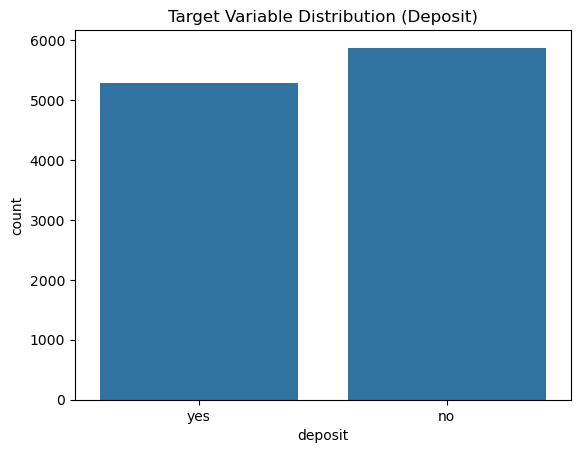

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='deposit', data=df)
plt.title("Target Variable Distribution (Deposit)")
plt.show()


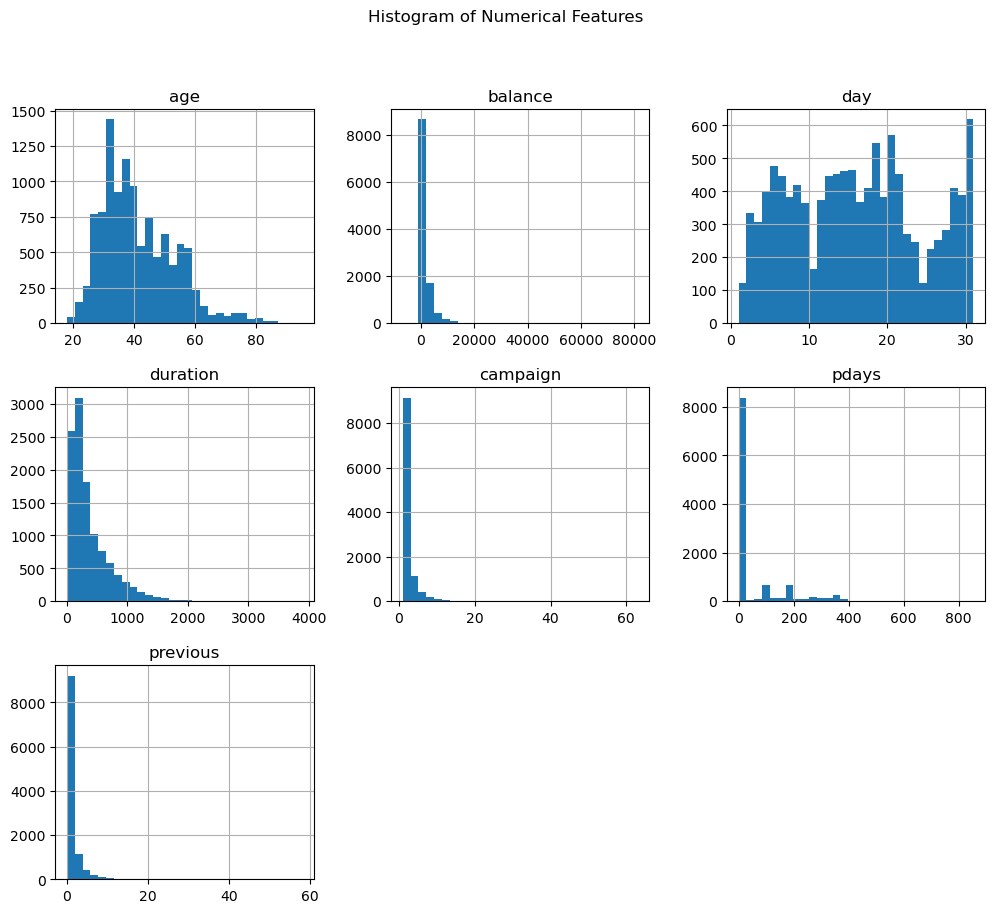

In [13]:
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

df[num_cols].hist(bins=30, figsize=(12,10))
plt.suptitle("Histogram of Numerical Features")
plt.show()


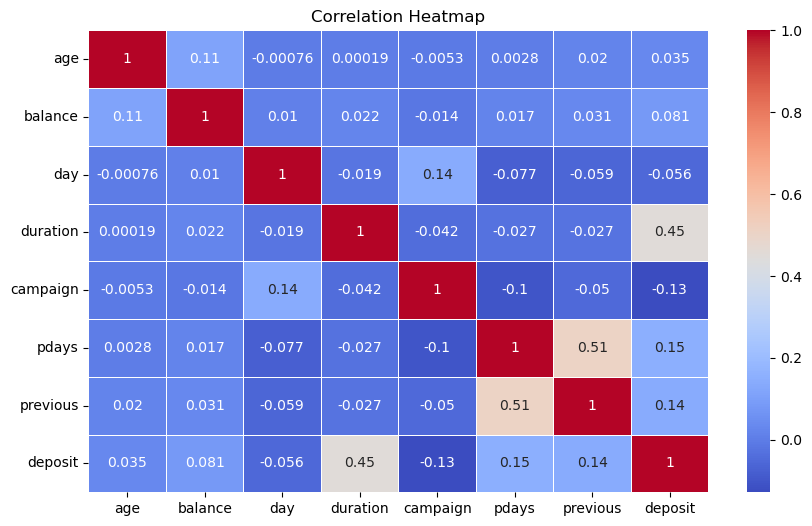

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols + ['deposit']].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [19]:
from sklearn.preprocessing import LabelEncoder

# Binary categorical columns
binary_cols = ['default', 'housing', 'loan', 'deposit']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-hot encode multi-class categorical variables
df = pd.get_dummies(df, columns=['job', 'marital', 'education', 'contact', 'month', 'poutcome'], drop_first=True)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']] = scaler.fit_transform(
    df[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']]
)


In [23]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['deposit'])  # Features
y = df['deposit']                 # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8078817733990148
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82      1166
           1       0.81      0.78      0.80      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



In [27]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7948947604120018
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80      1166
           1       0.78      0.80      0.79      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.80      0.79      0.79      2233

